In [14]:
root = "C:/Users/v-wangwilli/projects/nepas"
setwd(root)
.libPaths(file.path(root, "renv/library/windows/R-4.4/x86_64-w64-mingw32"))

library(jsonlite)
library(tidyverse)

source("script/processors.R")

In [2]:
bps = read_csv("data/cleaned_ocr/bps_final.csv")

Rows: 3204 Columns: 22
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): smsa, states, primary_state
dbl (19): year, total_units, private_total, private_1_unit, private_2_units,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# Missingness exploration

In [5]:
bps |>
  count(smsa) |>
  count(n)

Storing counts in `nn`, as `n` already present in input
ℹ Use `name = "new_name"` to pick a new name.


n,nn
<int>,<int>
1,6
2,5
3,6
5,11
6,3
7,7
9,32
11,3
12,120


In [7]:
bps |>
  count(year)

year,n
<dbl>,<int>
1967,225
1968,227
1969,227
1970,100
1971,260
1972,260
1973,263
1974,264
1975,271


In [ ]:
bps_13balanced = bps |>
  filter(.by = smsa, n() == 13)

In [11]:
expand_grid(
  bps |> filter(.by = smsa, n() == 12) |> distinct(smsa),
  year = 1967:1979
) |>
  anti_join(
    bps |> filter(.by = smsa, n() == 12),
    join_by(smsa, year)
  ) |>
  count(year)

year,n
<int>,<int>
1970,120


The MSAs with only one year missing are all missing 1970, the atypically small sample.

It doesn't look like the number of MSAs in the data increases during the permit expansion years of 1972 and 1973, which indicates to me that they mostly did within-MSA expansion.

In [72]:
options(repr.plot.width = 8, repr.plot.height = 8, repr.plot.res = 300)

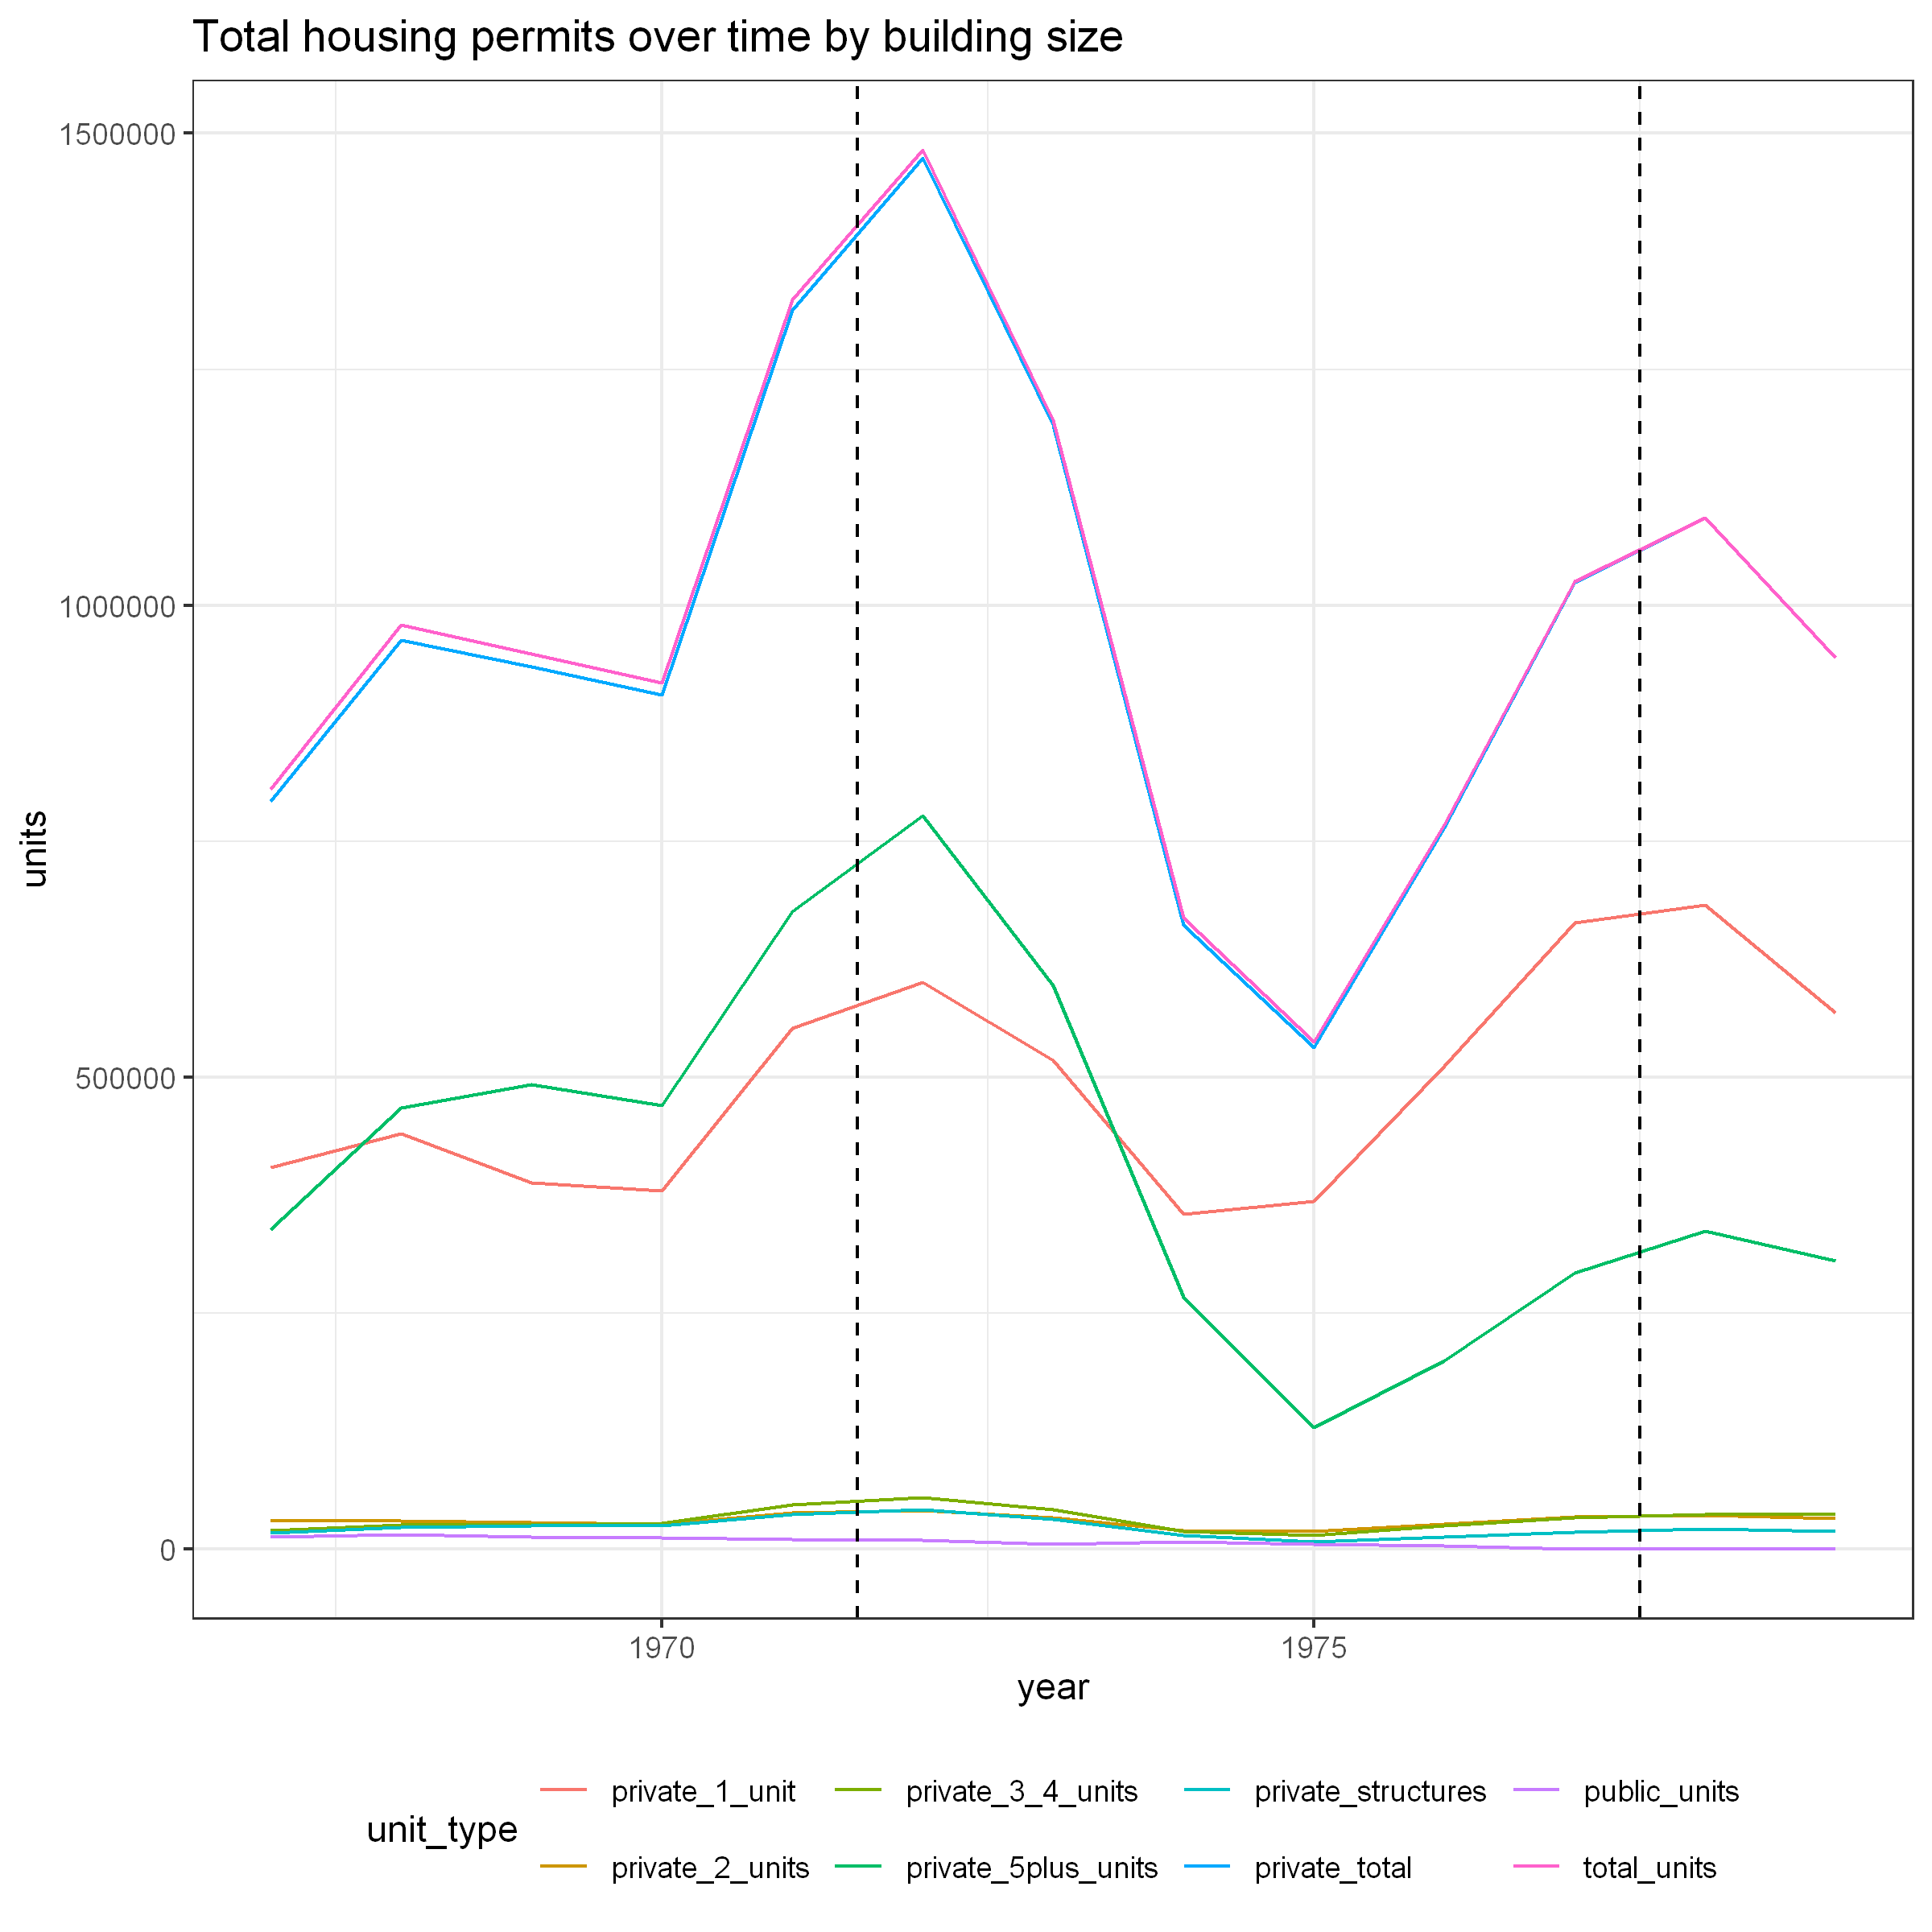

In [73]:
bps_13balanced |>
  summarize(
    .by = year,
    across(total_units:private_structures, \(x) sum(x, na.rm = TRUE))
  ) |>
  pivot_longer(!year, names_to = "unit_type", values_to = "units") |>
  ggplot() +
  geom_line(aes(x = year, y = units, col = unit_type)) +
  geom_vline(xintercept = c(1972, 1978) - 0.5, linetype = "dashed") +
  labs(title = "Total housing permits over time by building size") +
  custom_theme()

I don't see much evidence that permit expansion affected total permit count that much. I'll probably focus on 1 unit, 5+ unit, and total private construction here.

In [ ]:
# Largest metros
unit_categories = c("private_total", "private_1_unit", "private_5plus_units")

bps_13balanced |>
  pivot_longer(all_of(unit_categories), names_to = "unit_type", values_to = "units") |>
  filter(is.na(units) | units == 0)

smsa,year,total_units,private_2_units,private_3_4_units,public_units,private_structures,total_valuation,private_valuation,private_1_unit_val,⋯,private_3_4_units_val,private_5plus_units_val,public_valuation,states,primary_state,adoption_year,event_year,treat,unit_type,units
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
"COLORADO SPRINGS, COLO",1976,1381,8,0,0,0,33808,33808,33656,⋯,0,0,0,CO,CO,Inf,-Inf,0,private_5plus_units,0
"ROCHESTER, NY",1976,2835,36,55,0,0,95343,95343,93559,⋯,1172,0,0,NY,NY,1975,1,1,private_5plus_units,0


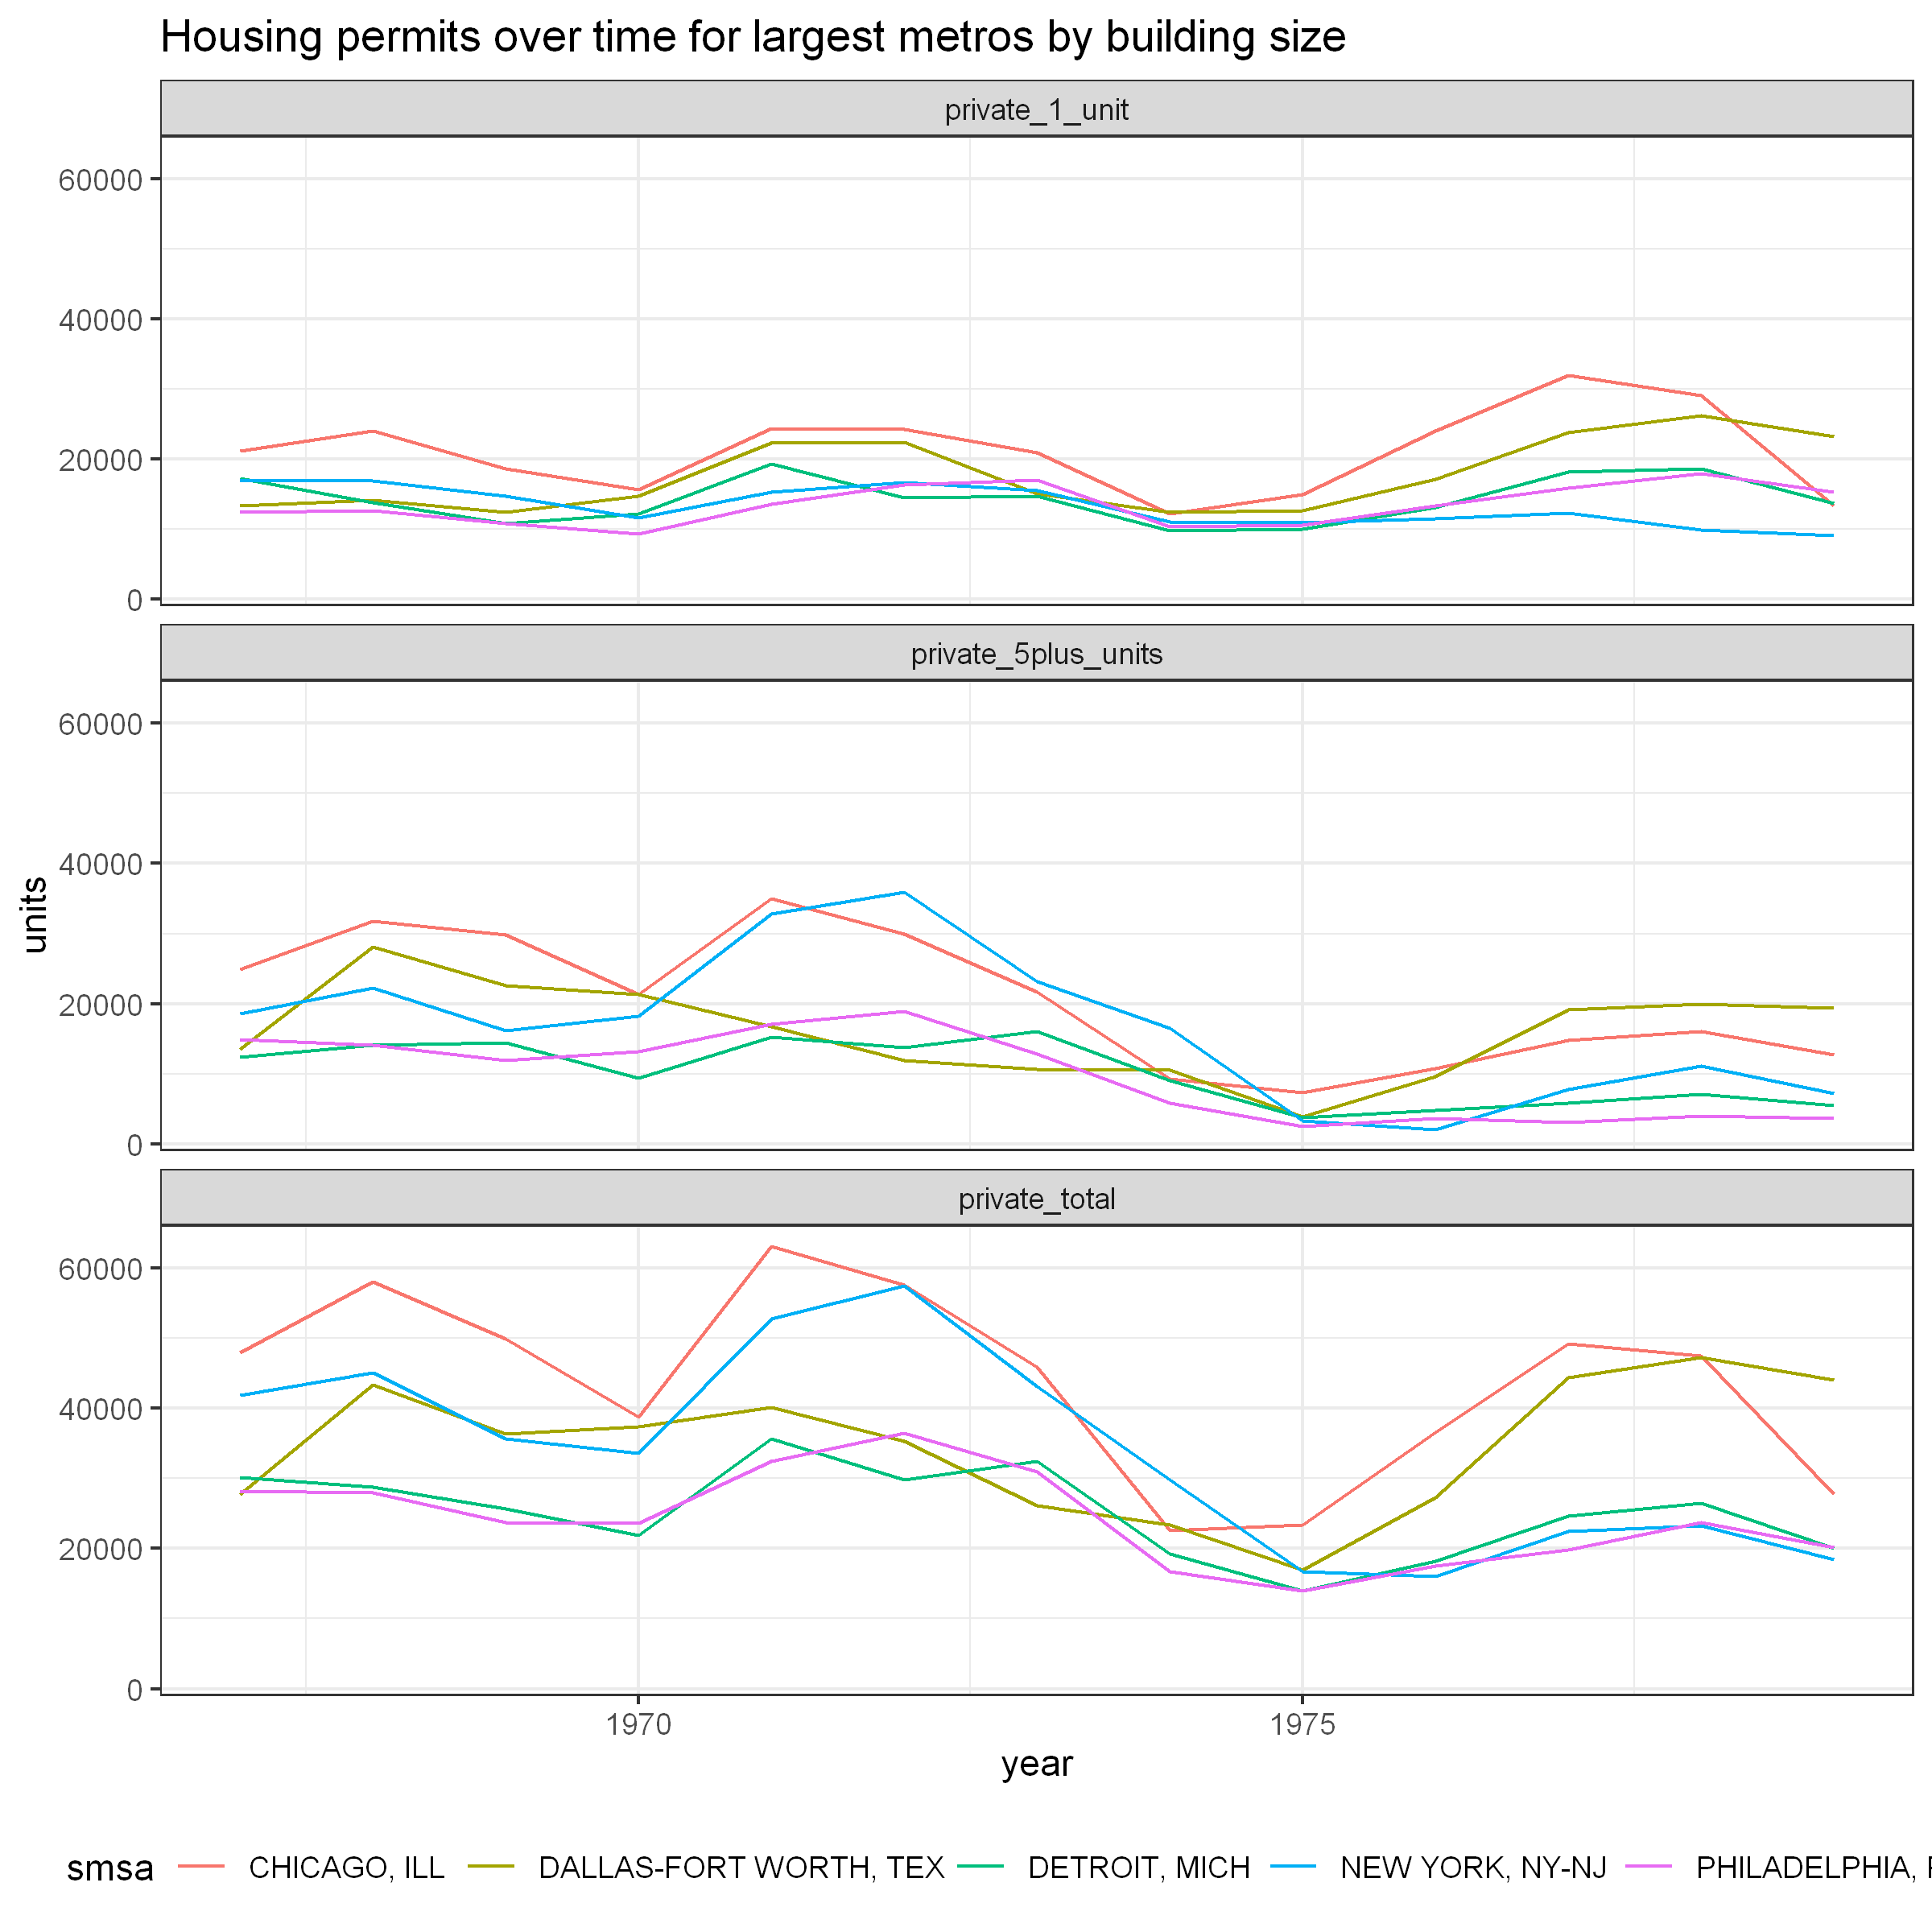

In [74]:
bps_13balanced |>
  mutate(.by = smsa, start_units = total_units[year == 1967]) |>
  filter(dense_rank(desc(start_units)) <= 5) |>
  pivot_longer(all_of(unit_categories), names_to = "unit_type", values_to = "units") |>
  ggplot() +
  geom_line(aes(x = year, y = units, col = smsa)) +
  facet_wrap(vars(unit_type), ncol = 1) +
  labs(title = "Housing permits over time for largest metros by building size") +
  custom_theme()

Similar trends across the top MSAs -- really stark decline to 1975 in construction. 

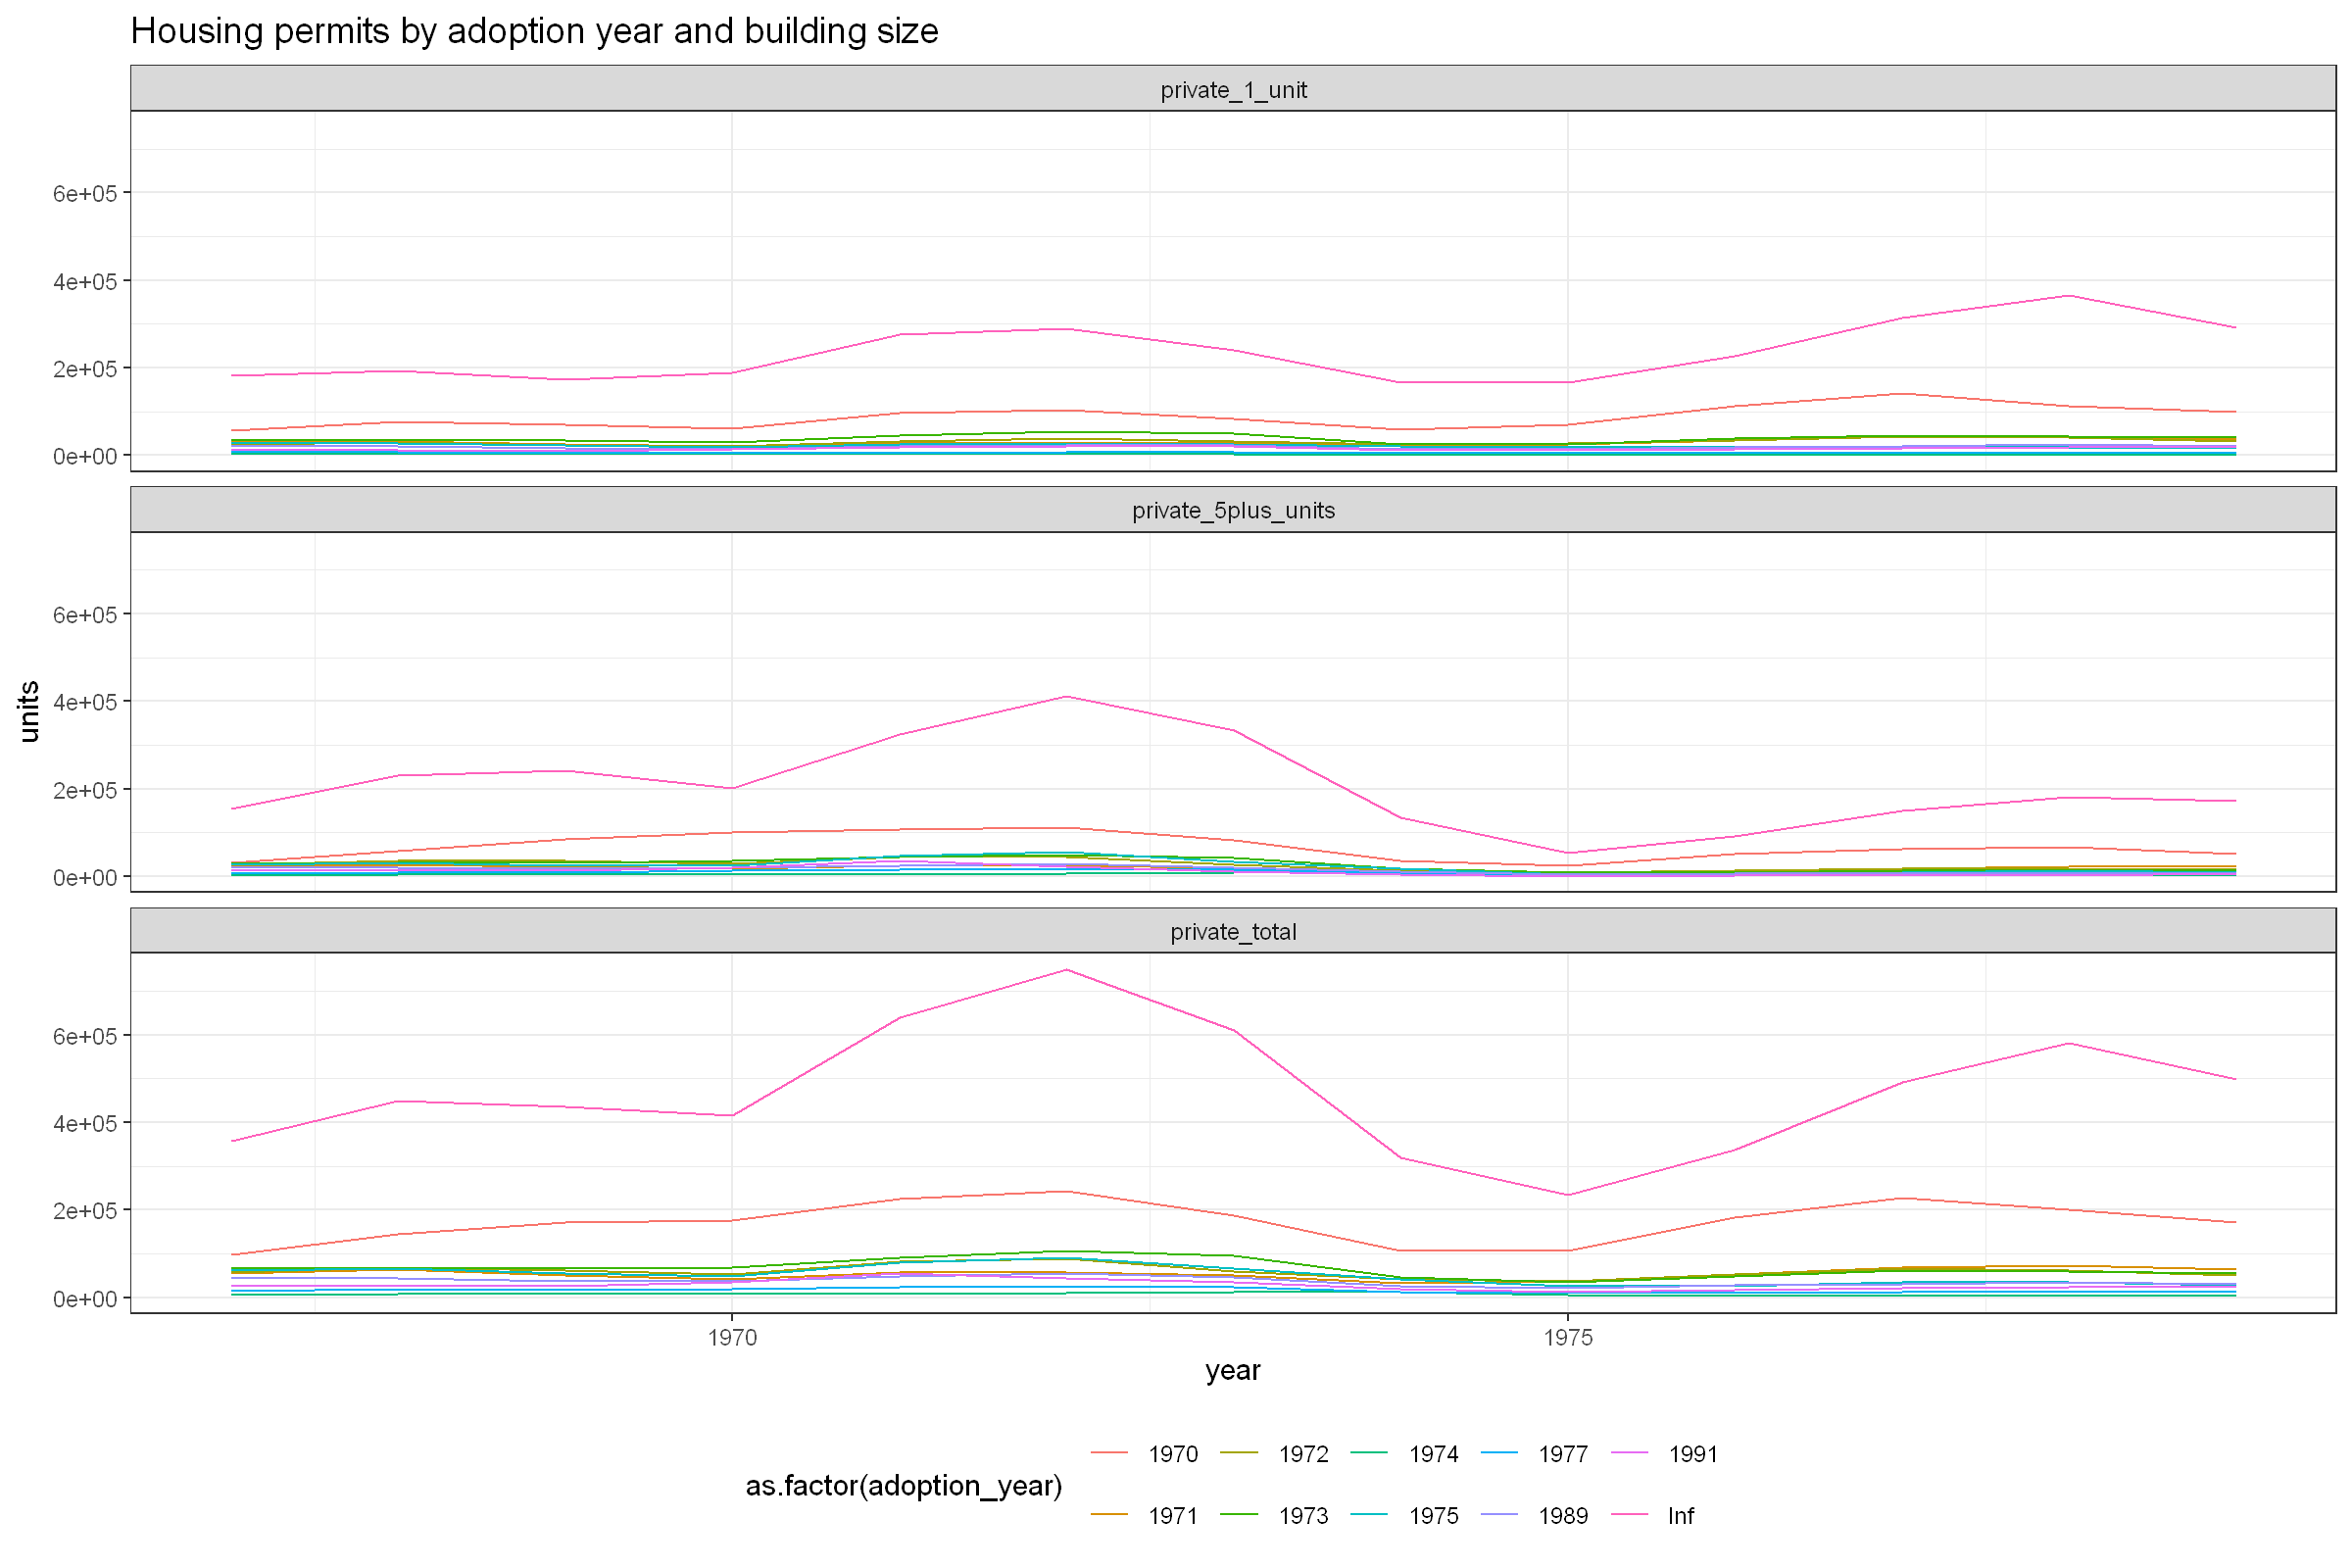

In [52]:
bps_13balanced |>
  summarize(
    .by = c(year, adoption_year),
    across(all_of(unit_categories), \(x) sum(x, na.rm = TRUE))
  ) |>
  pivot_longer(all_of(unit_categories), names_to = "unit_type", values_to = "units") |>
  ggplot() +
  geom_line(aes(x = year, y = units, col = as.factor(adoption_year))) +
  facet_wrap(vars(unit_type), ncol = 1) +
  labs(title = "Housing permits by adoption year and building size") +
  custom_theme()

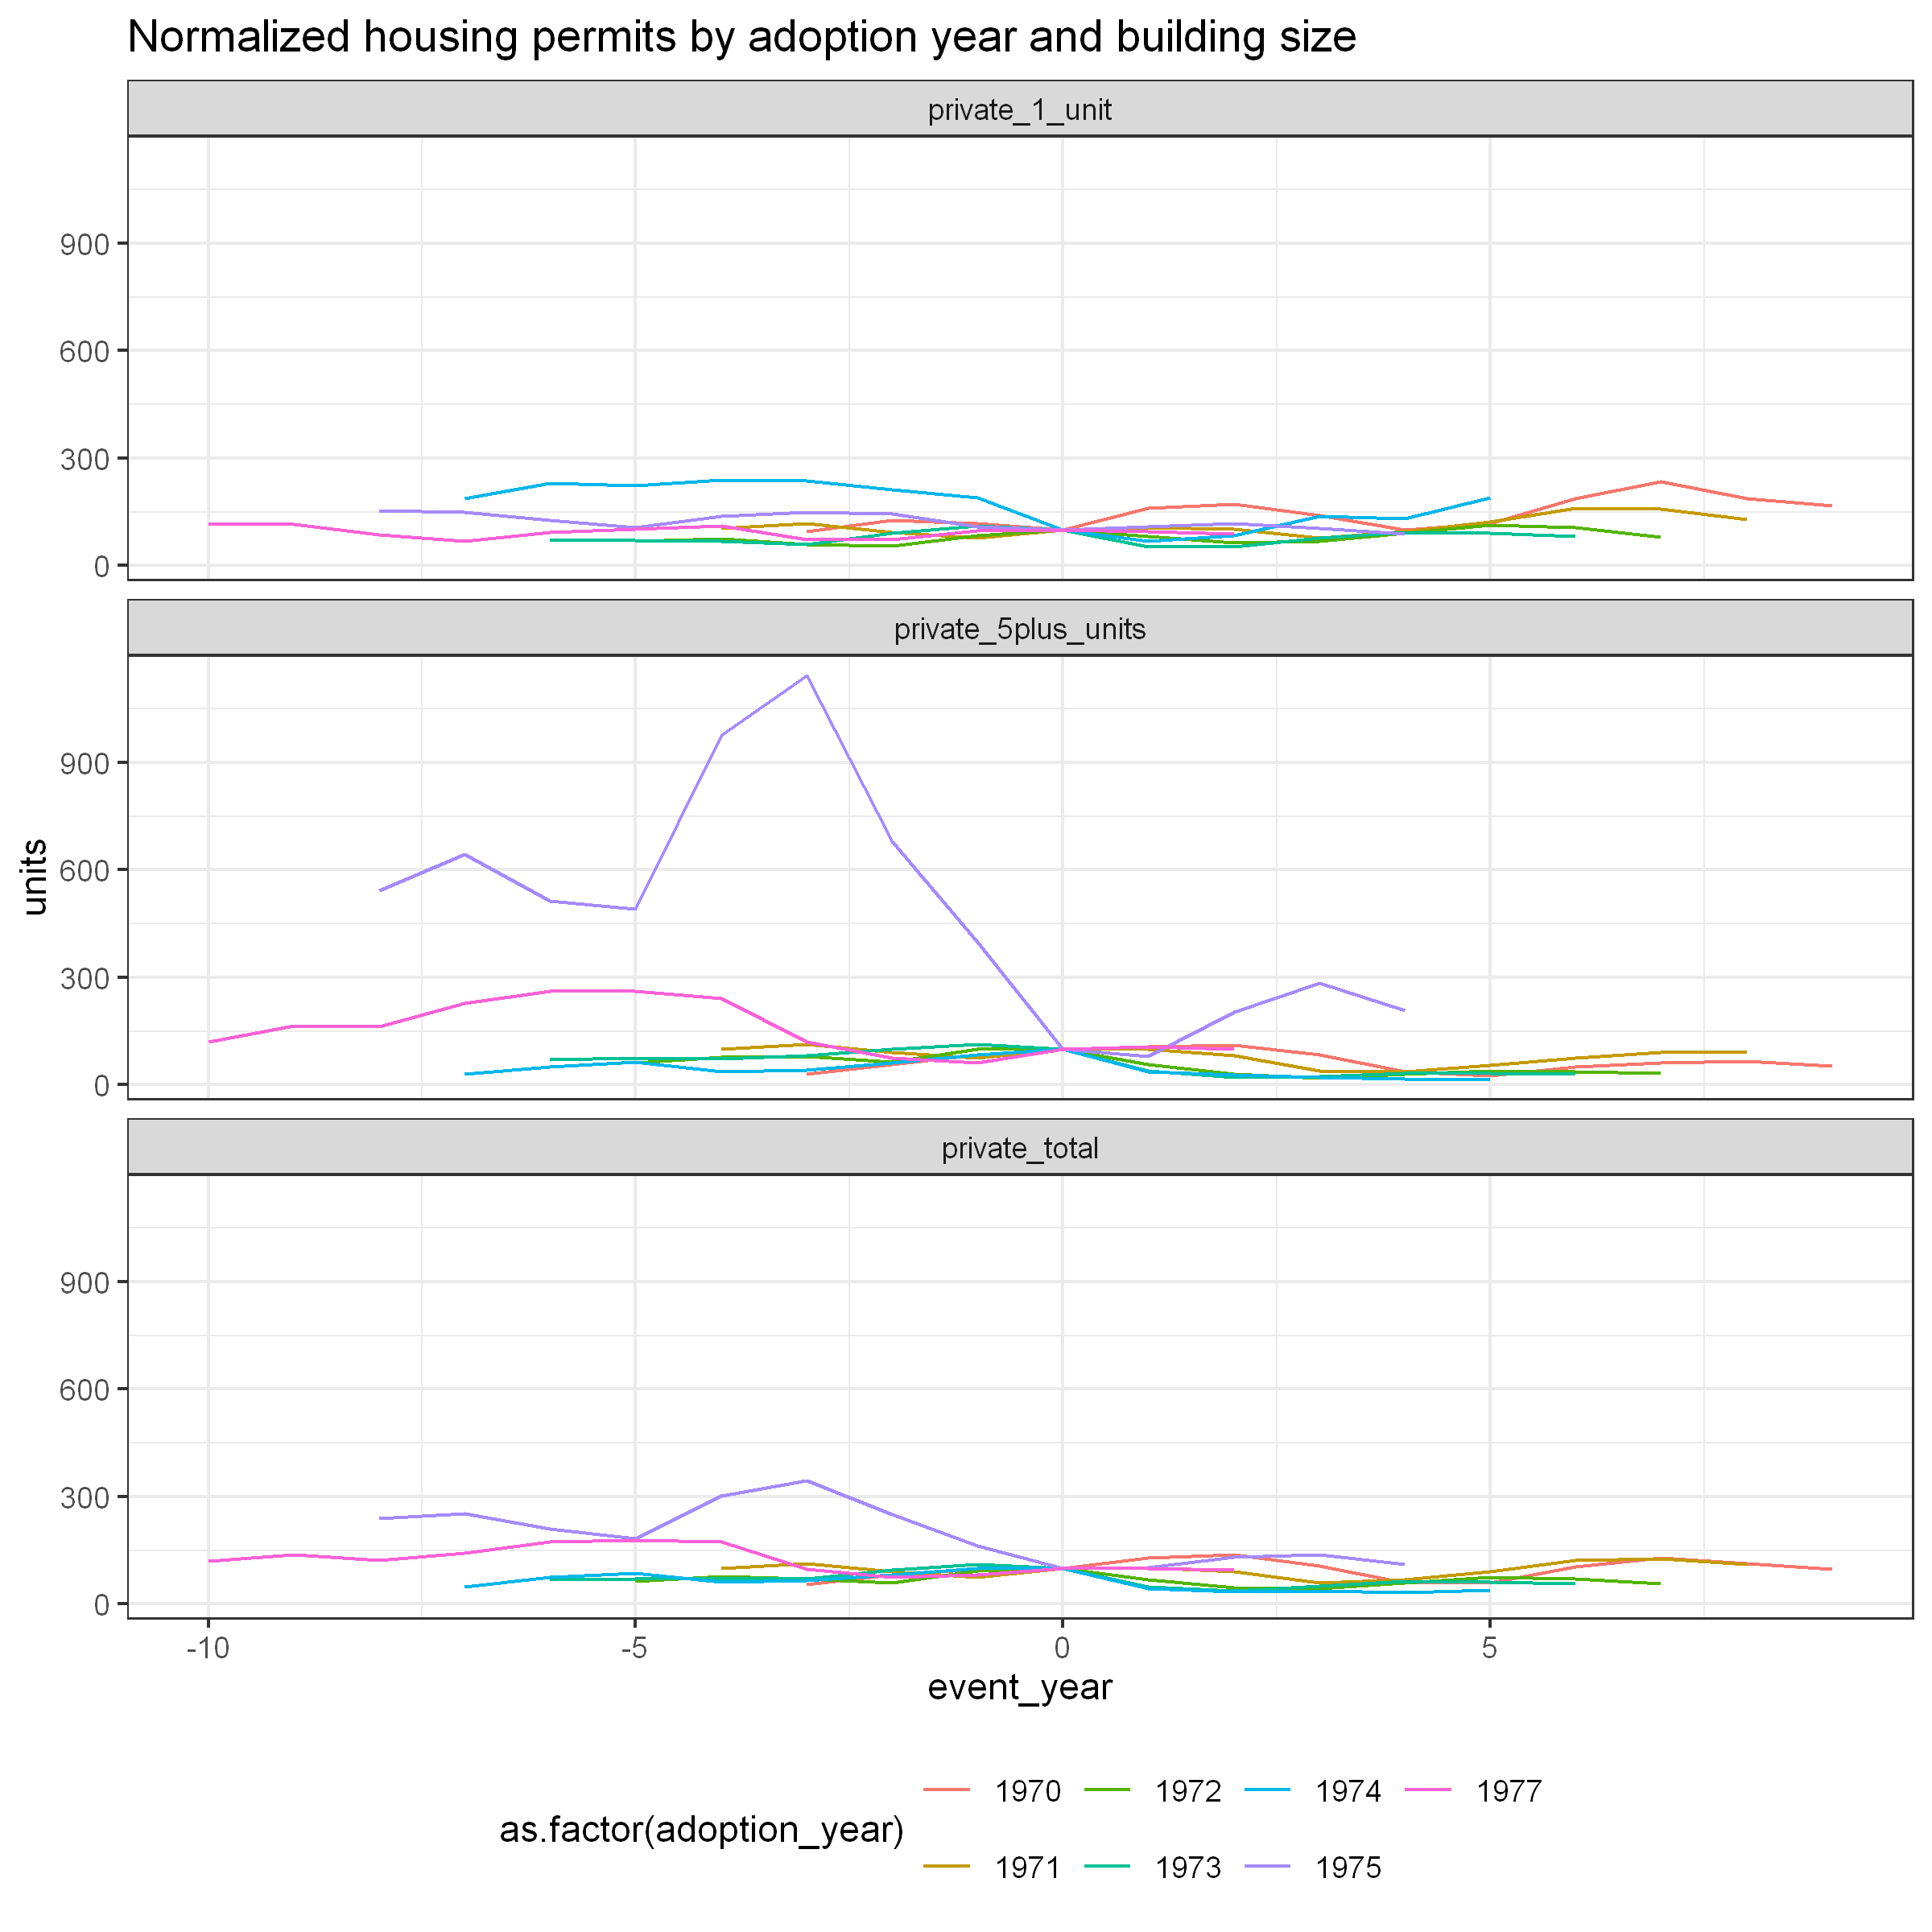

In [75]:
bps_13balanced |>
  filter(adoption_year < 1980) |>
  summarize(
    .by = c(event_year, adoption_year),
    across(all_of(unit_categories), \(x) sum(x, na.rm = TRUE))
  ) |>
  mutate(
    .by = adoption_year,
    across(all_of(unit_categories), \(x) x / x[event_year == 0] * 100)
  ) |>
  pivot_longer(all_of(unit_categories), names_to = "unit_type", values_to = "units") |>
  ggplot() +
  geom_line(aes(x = event_year, y = units, col = as.factor(adoption_year))) +
  facet_wrap(vars(unit_type), ncol = 1) +
  labs(title = "Normalized housing permits by adoption year and building size") +
  custom_theme()

New York (not just NYC) just has some crazy patterns going on during the recession. I'm afraid that I won't be able to get any signal from the noise because of the recession. 

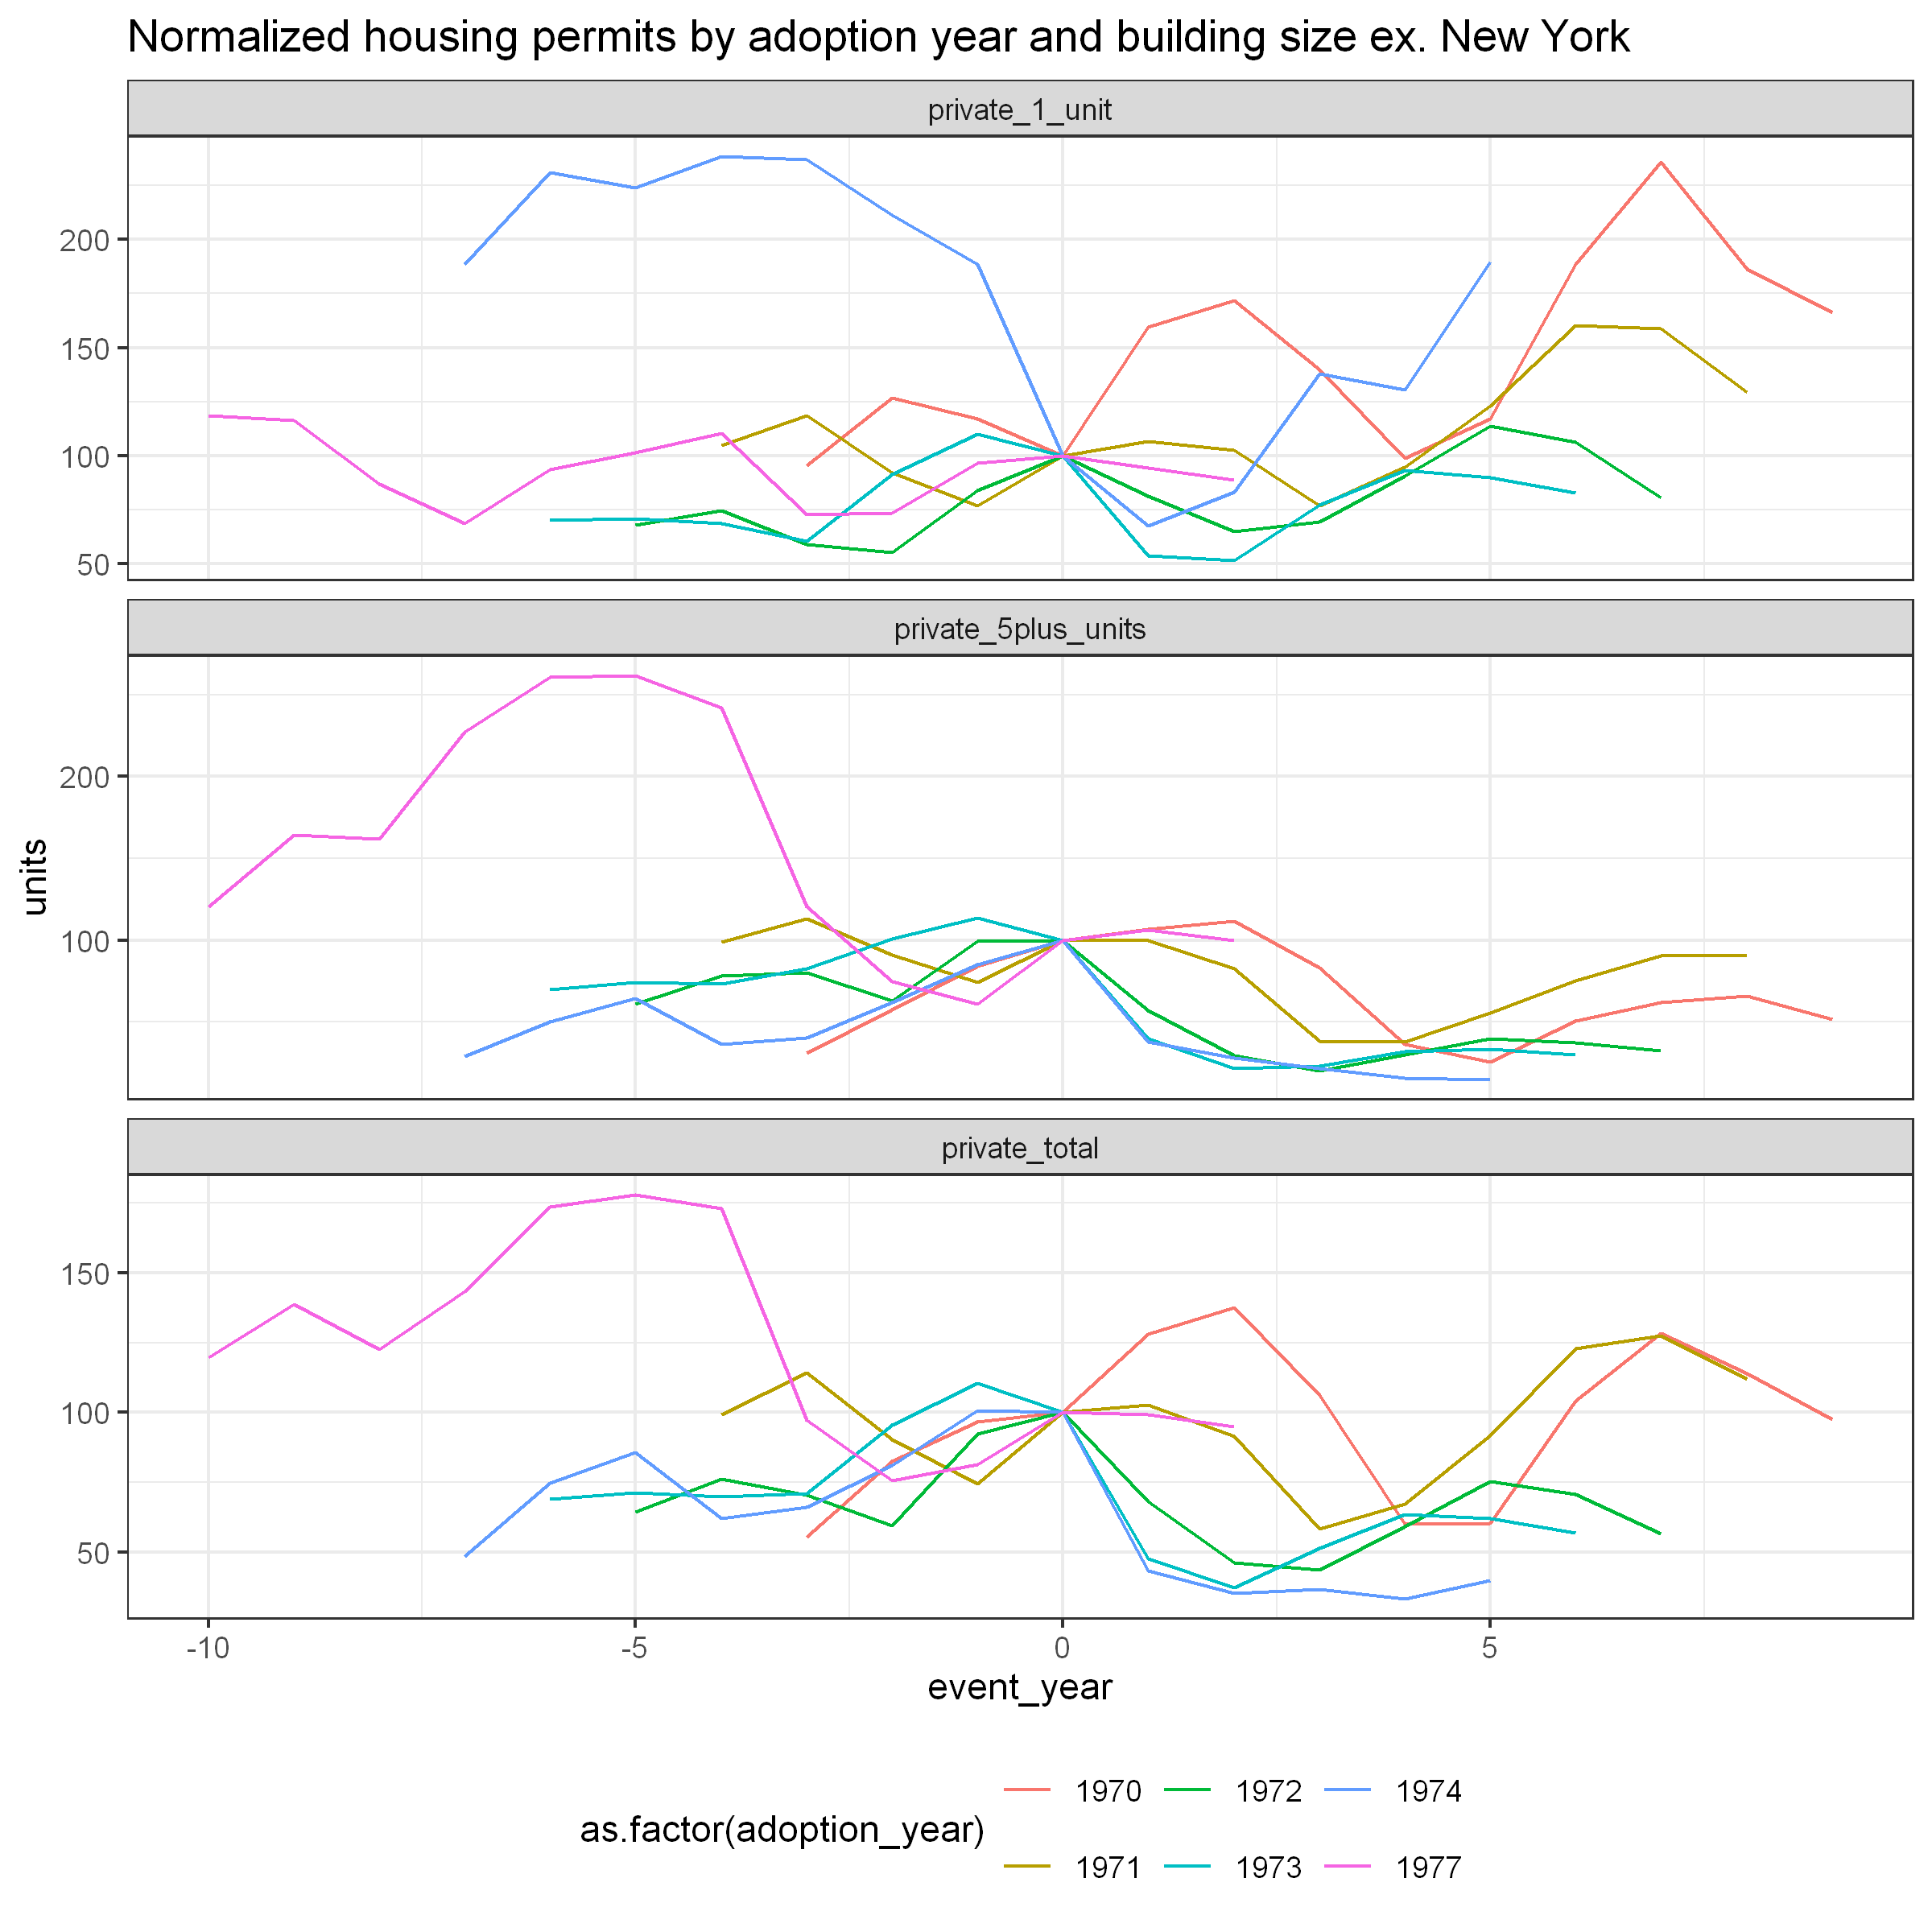

In [80]:
bps_13balanced |>
  filter(adoption_year < 1980 & !str_detect(states, "NY")) |>
  summarize(
    .by = c(event_year, adoption_year),
    across(all_of(unit_categories), \(x) sum(x, na.rm = TRUE))
  ) |>
  mutate(
    .by = adoption_year,
    across(all_of(unit_categories), \(x) x / x[event_year == 0] * 100)
  ) |>
  pivot_longer(all_of(unit_categories), names_to = "unit_type", values_to = "units") |>
  ggplot() +
  geom_line(aes(x = event_year, y = units, col = as.factor(adoption_year))) +
  facet_wrap(vars(unit_type), ncol = 1, scales = "free_y") +
  labs(title = "Normalized housing permits by adoption year and building size ex. New York") +
  custom_theme()

In [66]:
bps_13balanced |>
  filter(event_year == -3 & adoption_year == 1975) |>
  filter(!str_detect(smsa, "NEW YORK"))

smsa,year,total_units,private_total,private_1_unit,private_2_units,private_3_4_units,private_5plus_units,public_units,private_structures,⋯,private_1_unit_val,private_2_units_val,private_3_4_units_val,private_5plus_units_val,public_valuation,states,primary_state,adoption_year,event_year,treat
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
"ALBANY-SCHENECTADY-TROY, NY",1972,7410,7410,2388,208,80,4734,0,220,⋯,53862,3042,842,47089,0,NY,NY,1975,-3,0
"BUFFALO, NY",1972,9047,9047,3460,770,557,4260,0,325,⋯,70745,9123,7799,51532,0,NY,NY,1975,-3,0
"ROCHESTER, NY",1972,11493,11493,3368,200,544,7381,0,280,⋯,78878,3568,5925,115385,0,NY,NY,1975,-3,0
"SYRACUSE, NY",1972,5162,5162,1744,60,21,3337,0,131,⋯,35400,626,298,40339,0,NY,NY,1975,-3,0
